# Etapa 2 — Parte 2: Modelos Avanzados (Ensemble + Modelo sin Rezagos)
## Predicción de Brotes de Dengue en El Salvador
### Universidad de El Salvador — Ingeniería en sistemas informáticos
Este notebook desarrolla dos líneas de modelos avanzados:

**A. Ensembles** — combinan varios modelos para mejorar el desempeño:
- **Voting Regressor:** promedia las predicciones de Random Forest y XGBoost
- **Stacking Regressor:** un meta-modelo aprende a combinar las predicciones base

**B. Modelo sin rezagos de casos** — experimento para predicción a MAYOR PLAZO:- Se excluyen los rezagos de casos (que el MINSAL no puede conocer con antelación)- Se mantiene elen  clima y sus rezagos (que sí pueden estimarse con pronósticos)- Cuantifica cuánto del poder predictivo viene de la inercia de casos vs. el climaSe usan los hiperparámetros óptimos hallados en el notebook de optimización.

**División:** Train 2014-2019, Val 2020-2021, Test 2022-2024.

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
print('Librerías cargadas')

Librerías cargadas


## 2. Carga de datos y división

In [2]:
URL = 'https://raw.githubusercontent.com/Melvillalta1/DengueSV/refs/heads/main/dataset_pais_semana.csv'
df = pd.read_csv(URL)
df = df.sort_values(['anio_epi','semana_epi']).reset_index(drop=True)

train = df[df['anio_epi'].isin([2014,2015,2016,2017,2018,2019])].copy()
val   = df[df['anio_epi'].isin([2020,2021])].copy()
test  = df[df['anio_epi'].isin([2022,2023,2024])].copy()

# Para el modelo final, entrenamos con train+val juntos
train_full = pd.concat([train, val])

print(f'Train+Val: {len(train_full)} filas | Test: {len(test)} filas')

Train+Val: 418 filas | Test: 156 filas


## 3. Definir conjuntos de variablesDefinimos DOS conjuntos de predictoras:- **Completo:** todas las variables (incluye rezagos de casos)- **Sin rezagos de casos:** excluye casos_dengue_lag*, casos_promedio_4sem, casos_tendencia  (mantiene clima, rezagos de clima, estacionalidad y variables biológicas)

In [3]:
OBJETIVO = 'casos_dengue'
excluir_base = ['casos_dengue','anio_epi','calendar_start_date','calendar_end_date','indice_temporal']

# Conjunto completo
predictoras_completo = [c for c in df.columns if c not in excluir_base]

# Conjunto sin rezagos de casos
rezagos_casos = ['casos_dengue_lag1','casos_dengue_lag2','casos_dengue_lag3',
                 'casos_dengue_lag4','casos_promedio_4sem','casos_tendencia']
predictoras_sin_rezagos = [c for c in predictoras_completo if c not in rezagos_casos]

print(f'Variables conjunto COMPLETO: {len(predictoras_completo)}')
print(f'Variables SIN rezagos de casos: {len(predictoras_sin_rezagos)}')
print(f'\nVariables excluidas en el modelo sin rezagos:')
for r in rezagos_casos:
    print(f'  - {r}')
print(f'\nVariables que SÍ mantiene (clima, estacionalidad, biológicas):')
for p in predictoras_sin_rezagos:
    print(f'  - {p}')

Variables conjunto COMPLETO: 34
Variables SIN rezagos de casos: 28

Variables excluidas en el modelo sin rezagos:
  - casos_dengue_lag1
  - casos_dengue_lag2
  - casos_dengue_lag3
  - casos_dengue_lag4
  - casos_promedio_4sem
  - casos_tendencia

Variables que SÍ mantiene (clima, estacionalidad, biológicas):
  - semana_epi
  - t2m_max_sem
  - t2m_min_sem
  - t2m_prom_sem
  - precip_total
  - precip_dias_lluvia
  - humedad_prom
  - viento_prom
  - amplitud_termica
  - grados_dia
  - en_rango_optimo
  - dist_temp_optima
  - semana_lluviosa
  - estacion_lluviosa
  - semana_sin
  - semana_cos
  - t2m_prom_sem_lag1
  - t2m_prom_sem_lag2
  - t2m_prom_sem_lag3
  - t2m_prom_sem_lag4
  - precip_total_lag1
  - precip_total_lag2
  - precip_total_lag3
  - precip_total_lag4
  - humedad_prom_lag1
  - humedad_prom_lag2
  - humedad_prom_lag3
  - humedad_prom_lag4


## 4. Función de preparación y evaluación

In [4]:
def preparar(predictoras):
    Xtr = train_full[predictoras].copy()
    ytr = train_full[OBJETIVO].copy()
    Xte = test[predictoras].copy()
    yte = test[OBJETIVO].copy()
    # limpiar nulos de rezagos en train; rellenar en test
    mask = Xtr.notna().all(axis=1)
    Xtr, ytr = Xtr[mask], ytr[mask]
    Xte = Xte.fillna(0)
    return Xtr, np.log1p(ytr), Xte, yte

def evaluar(y_real, pred_log, nombre):
    pred_real = np.clip(np.expm1(pred_log), 0, None)
    mae = mean_absolute_error(y_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_real, pred_real))
    r2 = r2_score(y_real, pred_real)
    print(f'{nombre:34s} | MAE: {mae:7.2f} | RMSE: {rmse:7.2f} | R2: {r2:6.3f}')
    return {'modelo':nombre,'MAE':mae,'RMSE':rmse,'R2':r2}, pred_real

resultados = []

## 5. Modelos base con hiperparámetros óptimosUsamos los hiperparámetros encontrados en la optimización (notebook anterior).

In [5]:
# Hiperparámetros óptimos del notebook de optimización
def crear_rf():
    return RandomForestRegressor(max_depth=12, max_features=1.0, min_samples_leaf=5,
                                  n_estimators=500, random_state=42, n_jobs=-1)
def crear_xgb():
    return XGBRegressor(learning_rate=0.03, max_depth=3, n_estimators=200,
                        subsample=0.8, random_state=42, n_jobs=-1)

# Preparar datos con el conjunto completo
X_train, y_train_log, X_test, y_test_real = preparar(predictoras_completo)

# Baseline de referencia
baseline_pred = np.clip(test['casos_dengue_lag1'].fillna(0).values, 0, None)
mae_b = mean_absolute_error(y_test_real, baseline_pred)
rmse_b = np.sqrt(mean_squared_error(y_test_real, baseline_pred))
r2_b = r2_score(y_test_real, baseline_pred)
print(f'{"Baseline (lag1)":34s} | MAE: {mae_b:7.2f} | RMSE: {rmse_b:7.2f} | R2: {r2_b:6.3f}')
resultados.append({'modelo':'Baseline (lag1)','MAE':mae_b,'RMSE':rmse_b,'R2':r2_b})

# Modelos individuales optimizados (referencia)
rf = crear_rf(); rf.fit(X_train, y_train_log)
res, _ = evaluar(y_test_real, rf.predict(X_test), 'Random Forest optimizado')
resultados.append(res)

xgb = crear_xgb(); xgb.fit(X_train, y_train_log)
res, _ = evaluar(y_test_real, xgb.predict(X_test), 'XGBoost optimizado')
resultados.append(res)

Baseline (lag1)                    | MAE:   29.82 | RMSE:   50.86 | R2:  0.875
Random Forest optimizado           | MAE:   37.55 | RMSE:   54.15 | R2:  0.858
XGBoost optimizado                 | MAE:   34.07 | RMSE:   50.82 | R2:  0.875


## 6. Ensemble A — Voting Regressor

In [6]:
# Voting: promedia las predicciones de RF y XGBoost
voting = VotingRegressor([
    ('rf', crear_rf()),
    ('xgb', crear_xgb())
])
voting.fit(X_train, y_train_log)
print('=== VOTING REGRESSOR ===')
res, pred_voting = evaluar(y_test_real, voting.predict(X_test), 'Ensemble Voting (RF+XGB)')
resultados.append(res)

=== VOTING REGRESSOR ===
Ensemble Voting (RF+XGB)           | MAE:   34.76 | RMSE:   50.93 | R2:  0.874


## 7. Ensemble B — Stacking Regressor

In [7]:
# Stacking: un meta-modelo (Ridge) aprende a combinar RF y XGBoost
stacking = StackingRegressor(
    estimators=[('rf', crear_rf()), ('xgb', crear_xgb())],
    final_estimator=Ridge(),
    cv=5
)
stacking.fit(X_train, y_train_log)
print('=== STACKING REGRESSOR ===')
res, pred_stacking = evaluar(y_test_real, stacking.predict(X_test), 'Ensemble Stacking (RF+XGB->Ridge)')
resultados.append(res)

=== STACKING REGRESSOR ===
Ensemble Stacking (RF+XGB->Ridge)  | MAE:   37.86 | RMSE:   55.41 | R2:  0.851


## 8. Comparación de ensembles vs modelos individuales

=== COMPARACIÓN (Test 2022-2024) ===

                           modelo       MAE      RMSE       R2
                  Baseline (lag1) 29.820513 50.861804 0.874565
         Random Forest optimizado 37.551438 54.153614 0.857803
               XGBoost optimizado 34.072018 50.822387 0.874759
         Ensemble Voting (RF+XGB) 34.761524 50.930038 0.874228
Ensemble Stacking (RF+XGB->Ridge) 37.858355 55.407883 0.851140


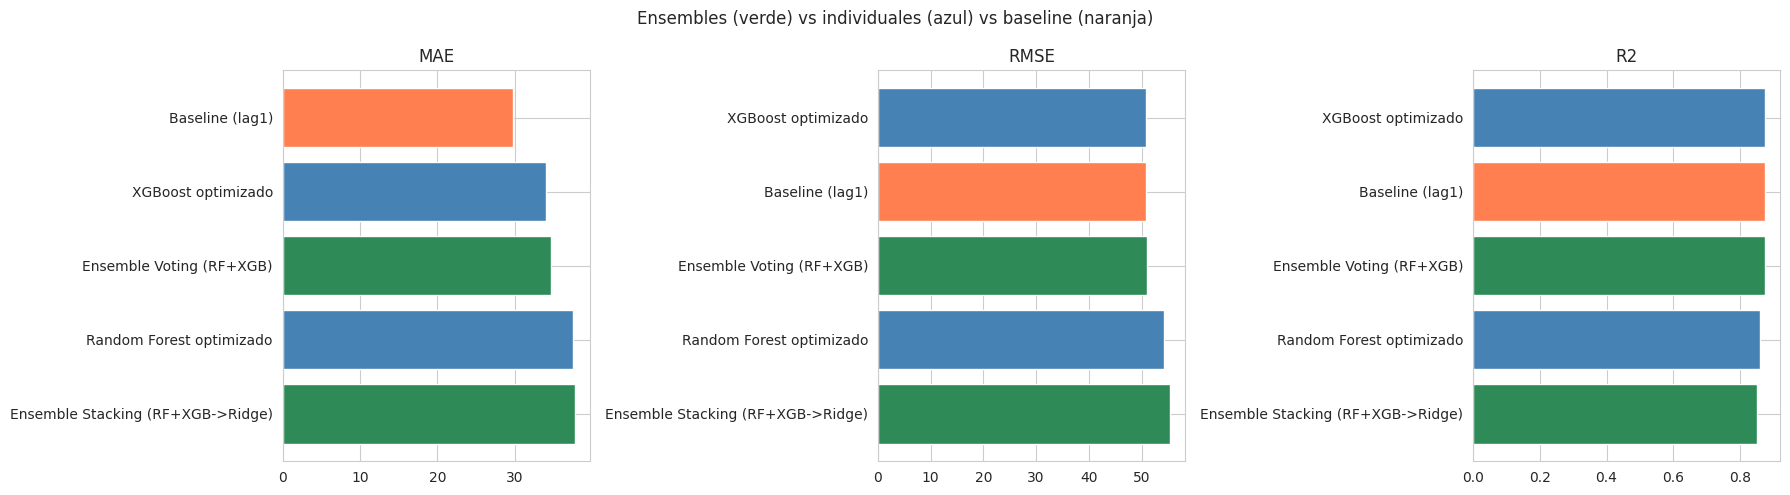

In [8]:
comp = pd.DataFrame(resultados)
print('=== COMPARACIÓN (Test 2022-2024) ===\n')
print(comp.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, met in zip(axes, ['MAE','RMSE','R2']):
    datos = comp.sort_values(met, ascending=(met!='R2'))
    colores = ['seagreen' if 'Ensemble' in m else ('coral' if 'Baseline' in m else 'steelblue') for m in datos['modelo']]
    ax.barh(datos['modelo'], datos[met], color=colores)
    ax.set_title(met); ax.invert_yaxis()
plt.suptitle('Ensembles (verde) vs individuales (azul) vs baseline (naranja)')
plt.tight_layout(); plt.show()

## 9. Modelo SIN rezagos de casos (predicción a mayor plazo)Ahora entrenamos excluyendo los rezagos de casos. Este modelo representa el escenariodonde NO se conocen los casos recientes (predicción anticipada), apoyándose solo enclima, estacionalidad y variables biológicas.

In [9]:
# Preparar datos SIN rezagos de casos
X_train_sr, y_train_log_sr, X_test_sr, y_test_real_sr = preparar(predictoras_sin_rezagos)

resultados_sr = []

# Random Forest sin rezagos
rf_sr = crear_rf(); rf_sr.fit(X_train_sr, y_train_log_sr)
print('=== MODELOS SIN REZAGOS DE CASOS ===')
res, pred_rf_sr = evaluar(y_test_real_sr, rf_sr.predict(X_test_sr), 'Random Forest sin rezagos')
resultados_sr.append(res)

# XGBoost sin rezagos
xgb_sr = crear_xgb(); xgb_sr.fit(X_train_sr, y_train_log_sr)
res, pred_xgb_sr = evaluar(y_test_real_sr, xgb_sr.predict(X_test_sr), 'XGBoost sin rezagos')
resultados_sr.append(res)

# Stacking sin rezagos
stacking_sr = StackingRegressor(
    estimators=[('rf', crear_rf()), ('xgb', crear_xgb())],
    final_estimator=Ridge(), cv=5)
stacking_sr.fit(X_train_sr, y_train_log_sr)
res, pred_stack_sr = evaluar(y_test_real_sr, stacking_sr.predict(X_test_sr), 'Stacking sin rezagos')
resultados_sr.append(res)

=== MODELOS SIN REZAGOS DE CASOS ===
Random Forest sin rezagos          | MAE:  195.97 | RMSE:  290.13 | R2: -3.082
XGBoost sin rezagos                | MAE:  228.36 | RMSE:  368.79 | R2: -5.595
Stacking sin rezagos               | MAE:  109.50 | RMSE:  150.55 | R2: -0.099


## 10. Comparación clave: CON vs SIN rezagos de casos

In [10]:
# Comparar el mejor modelo con rezagos vs sin rezagos
comparacion_final = pd.DataFrame([
    {'Escenario':'CON rezagos (Stacking)', 'MAE':comp[comp['modelo'].str.contains('Stacking')]['MAE'].values[0],
     'R2':comp[comp['modelo'].str.contains('Stacking')]['R2'].values[0]},
    {'Escenario':'SIN rezagos (Stacking)', 'MAE':resultados_sr[2]['MAE'], 'R2':resultados_sr[2]['R2']},
])
print('=== IMPACTO DE QUITAR LOS REZAGOS DE CASOS ===\n')
print(comparacion_final.to_string(index=False))

caida_r2 = comparacion_final['R2'].values[0] - comparacion_final['R2'].values[1]
print(f'\nCaída en R2 al quitar rezagos: {caida_r2:.3f}')
print('Esto cuantifica cuánto del poder predictivo proviene de la inercia de casos.')

=== IMPACTO DE QUITAR LOS REZAGOS DE CASOS ===

             Escenario        MAE        R2
CON rezagos (Stacking)  37.858355  0.851140
SIN rezagos (Stacking) 109.497578 -0.098935

Caída en R2 al quitar rezagos: 0.950
Esto cuantifica cuánto del poder predictivo proviene de la inercia de casos.


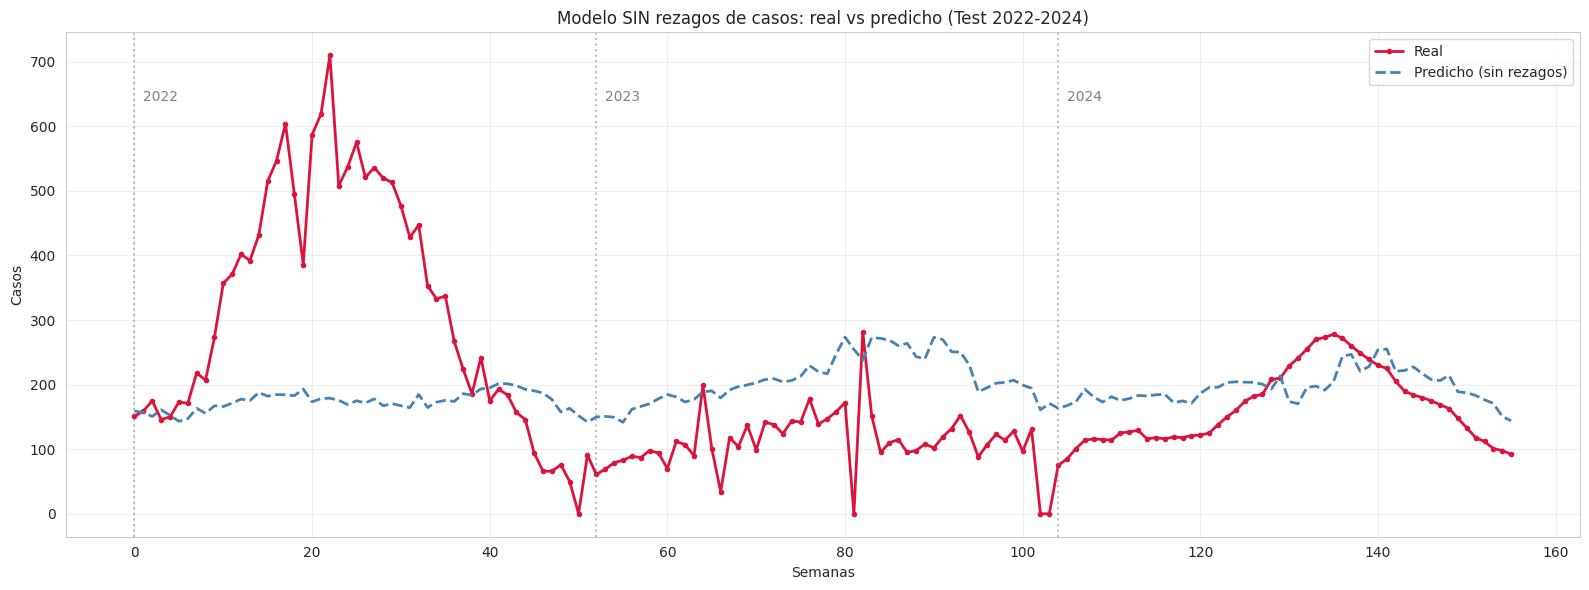

In [11]:
# Gráfica: predicción sin rezagos vs realidad en el test
test_sr = test.copy()
test_sr['prediccion'] = pred_stack_sr
test_sr = test_sr.sort_values(['anio_epi','semana_epi']).reset_index(drop=True)
test_sr['idx'] = range(len(test_sr))

plt.figure(figsize=(16, 6))
plt.plot(test_sr['idx'], test_sr['casos_dengue'], color='crimson', linewidth=2,
         marker='o', markersize=3, label='Real')
plt.plot(test_sr['idx'], test_sr['prediccion'], color='steelblue', linewidth=2,
         linestyle='--', label='Predicho (sin rezagos)')
for anio in [2022,2023,2024]:
    idx = test_sr[test_sr['anio_epi']==anio]['idx'].min()
    plt.axvline(idx, color='gray', linestyle=':', alpha=0.5)
    plt.text(idx+1, test_sr['casos_dengue'].max()*0.9, str(anio), color='gray')
plt.title('Modelo SIN rezagos de casos: real vs predicho (Test 2022-2024)')
plt.xlabel('Semanas'); plt.ylabel('Casos'); plt.legend()
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### 11. Conclusiones
### Ensembles
| Modelo | MAE | R² |
|--------|-----|-----|
| Random Forest optimizado | ___ | ___ |
| XGBoost optimizado | ___ | ___ |
| Ensemble Voting | ___ | ___ |
| Ensemble Stacking | ___ | ___ |

- ¿El ensemble superó a los modelos individuales? _____- ¿Algún ensemble superó al baseline? _____
### Modelo sin rezagos (predicción a mayor plazo)-
**R² con rezagos:** _____ vs **R² sin rezagos:** _____- **Caída de desempeño:** _____-

**Interpretación:** La caída cuantifica cuánto del poder predictivo proviene de la  autocorrelación de casos. Aunque el modelo sin rezagos es menos preciso, es el ÚNICO  aplicable para predicción anticipada (semanas o meses antes), ya que no requiere conocer  los casos recientes — solo clima (estimable con pronósticos) y estacionalidad.### Valor para la salud pública- El modelo CON rezagos sirve para vigilancia de corto plazo (predecir la próxima semana)- El modelo SIN rezagos sirve para planificación de mediano/largo plazo (anticipar temporadas  de riesgo con antelación), que es donde el MINSAL puede tomar acciones preventivas- Ambos son complementarios: responden preguntas distintas con horizontes distintos

### Próximos pasos
1. Análisis de sesgos y ética (fairness)
2. Prototipo funcional (Streamlit)
3. Análisis de impacto social y recomendaciones